  **Capstone Project(The Palmer Penguins
Classification
Challenge)**


**Phase 1: Data Loading & Cleaning**

In [5]:
import seaborn as sb
import pandas as pd
import numpy as nm
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
df=sb.load_dataset("penguins")

print("First 5 rows:")
print(df.head())
print("Dataset Info:")
print(df.info())
print("Statistical Summary:")
print(df.describe(include="all"))


print("\n--Null Values--")
print(df.isnull().sum())


df_clean=df.dropna()

print("\nMissing Value After Cleaning:")
print(df_clean.isnull().sum())
print("\nClean dataset Shape:",df_clean.shape)


First 5 rows:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-n

**Phase 2: The Model Race (Training)**

In [6]:
X=df_clean[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]]
y=df_clean["species"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(f"Training Set size: {X_train.shape[0]} samples")
print(f"Testing Set size: {X_test.shape[0]} samples")
knn_model=KNeighborsClassifier()
knn_model.fit(X_train,y_train)
knn_y_pred=knn_model.predict(X_test)


dt_model=DecisionTreeClassifier()
dt_model.fit(X_train,y_train)
dt_y_pred=dt_model.predict(X_test)
print("\nModels have been successfully trained and evaluated")

Training Set size: 266 samples
Testing Set size: 67 samples

Models have been successfully trained and evaluated


**Phase 3: The Proof (Evaluation & Interpretability)**

K-Nearest Neighbors Accuracy: 0.8208955223880597
Decision Tree Accuracy: 0.9850746268656716

Generate Confusion Matrix for the best performing model: Decision Tree


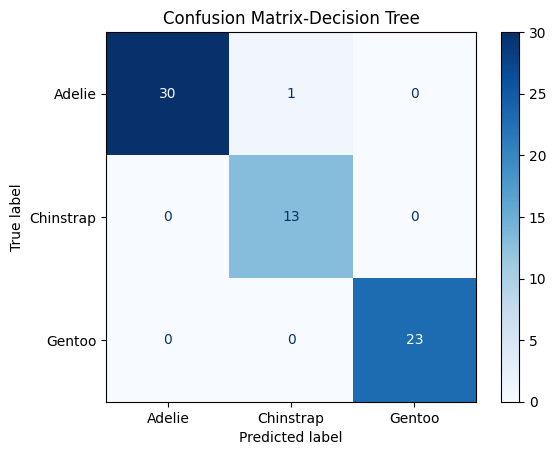


Feature Importance(Decision Tree Interpretability):


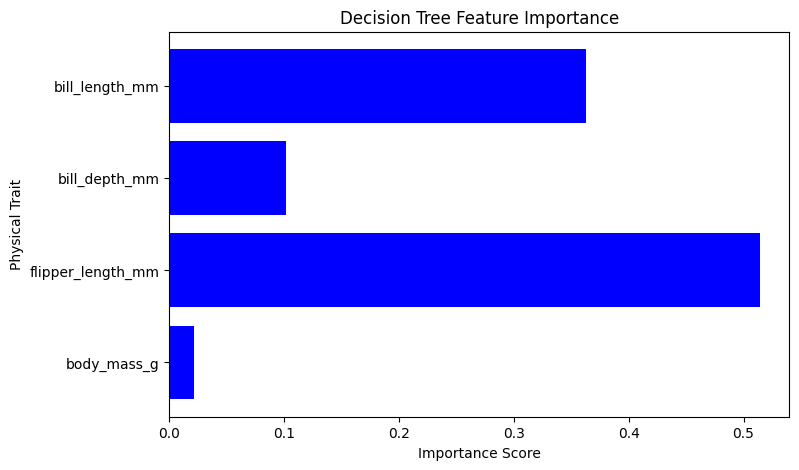

Feature:bill_length_mm       Importance:0.362951
Feature:bill_depth_mm        Importance:0.101325
Feature:flipper_length_mm    Importance:0.514131
Feature:body_mass_g          Importance:0.021593


In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn_accuracy=accuracy_score(y_test,knn_y_pred)
dt_accuracy=accuracy_score(y_test,dt_y_pred)

print("K-Nearest Neighbors Accuracy:",knn_accuracy)
print("Decision Tree Accuracy:",dt_accuracy)

# Determine the best model based on accuracy
if dt_accuracy>=knn_accuracy:
  best_model="Decision Tree"
  best_preds=dt_y_pred
else:
  best_model="K-Nearest Neighbors"
  best_preds=knn_y_pred

# Generate Confusion Matrix for the best performing model
print(f"\nGenerate Confusion Matrix for the best performing model: {best_model}")
cm=confusion_matrix(y_test,best_preds)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=dt_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix-{best_model}")
plt.show()

# Decision Tree Interpretability (always show feature importance)
print("\nFeature Importance(Decision Tree Interpretability):")
importances=dt_model.feature_importances_
feature_names=X.columns

plt.figure(figsize=(8,5))
plt.barh(feature_names,importances,color="blue")
plt.xlabel('Importance Score')
plt.ylabel("Physical Trait")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.show()

for name,importance in zip(feature_names,importances):
  print(f"Feature:{name:20} Importance:{importance:4f}")